<a href="https://colab.research.google.com/github/solehas25h-salmasoleha/Co-Kriging/blob/main/Co_Kriging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classic Co-Kriging Analysis
## California Housing Dataset

## Pendahuluan

Co-Kriging merupakan metode interpolasi spasial
yang digunakan untuk memprediksi suatu variabel utama
dengan memanfaatkan informasi dari variabel lain
yang memiliki hubungan spasial.


Dalam penelitian ini digunakan:


Variabel utama (Z1):

Median House Value


Variabel sekunder (Z2):

Median Income


Informasi spasial:

Longitude dan Latitude


Tujuan analisis adalah membangun model Co-Kriging
klasik dengan mempertimbangkan:

1. Variogram variabel utama (Z1)
2. Variogram variabel sekunder (Z2)
3. Cross variogram Z1-Z2
4. Model koregionalisasi
5. Prediksi nilai pada lokasi yang tidak diamati

# 2. INSTALL LIBRARY

In [7]:

!pip install scikit-gstat
!pip install pykrige

# 3. Import Library

Tahap ini memanggil seluruh library yang diperlukan
untuk proses analisis data spasial.

Analisis meliputi:

- eksplorasi data,
- perhitungan variogram,
- cross variogram,
- visualisasi spasial.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from scipy.spatial.distance import (
    pdist,
    squareform
)
from scipy.stats import pearsonr
from skgstat import Variogram
print(
    "Library berhasil dimuat"
)

Library berhasil dimuat


# 4. UPLOAD DATASET
## Input Dataset

Dataset yang digunakan adalah California Housing Dataset.

Data berisi informasi:

- lokasi geografis,
- kondisi ekonomi,
- nilai median rumah.

In [9]:

uploaded = files.upload()

Saving housing.csv to housing (1).csv


# 5. MEMBACA DATA

In [10]:
filecose = list(uploaded.keys())[0]
df = pd.read_csv(filecose)
print(
    "Nama file:",
    filecose
)
print(
    "Ukuran dataset:",
    df.shape
)
df.head()

Nama file: housing (1).csv
Ukuran dataset: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Pemeriksaan Dataset

Dataset diperiksa untuk mengetahui:

- jumlah observasi,
- struktur variabel,
- format data.

Variabel yang akan digunakan:

longitude:
koordinat X

latitude:
koordinat Y

median_house_value:
variabel utama (Z1)

median_income:
variabel sekunder (Z2)

# 6. PEMBERSIHAN DATA
## Data Cleaning

Data kosong dihapus agar tidak mengganggu
perhitungan variogram dan proses interpolasi spasial.

In [11]:

df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [12]:
df = df.dropna()

# 7. PERSIAPAN VARIABEL CO-KRIGING

In [13]:
# Primary variable Z1
Z1 = df[
    "median_house_value"
].values
# Secondary variable Z2
Z2 = df[
    "median_income"
].values
# Spatial coordinate

coords = df[
    [
        "longitude",
        "latitude"
    ]
].values
print(
    "Z1:",
    Z1.shape
)
print(
    "Z2:",
    Z2.shape
)
print(
    "Coordinate:",
    coords.shape
)

Z1: (20433,)
Z2: (20433,)
Coordinate: (20433, 2)


## Definisi Variabel Co-Kriging

Pada Co-Kriging digunakan:

Z1:
Variabel yang akan diprediksi.
Dalam penelitian ini:
Median House Value.


Z2:
Variabel tambahan yang memiliki hubungan spasial.
Dalam penelitian ini:
Median Income.


Coordinate:
Lokasi setiap observasi berdasarkan longitude
dan latitude.

# 8. SAMPLING DATA
## Sampling Spasial

Karena Co-Kriging klasik membutuhkan perhitungan
matriks spasial, digunakan 500 titik sampel.

Sampling dilakukan secara acak dengan random_state=42
agar hasil dapat direplikasi.

In [14]:
# RANDOM SAMPLING

data = df[
    [
        "longitude",
        "latitude",
        "median_house_value",
        "median_income"
    ]
].dropna()
data_sample = data.sample(
    n=500,
    random_state=42
)
coords = data_sample[
    [
        "longitude",
        "latitude"
    ]
].values
Z1 = data_sample[
    "median_house_value"
].values
Z2 = data_sample[
    "median_income"
].values
print(
    data_sample.shape
)

(500, 4)


# 9. Exploratory Spatial Analysis

## 9.1 — Peta Z1 (Median House Value)

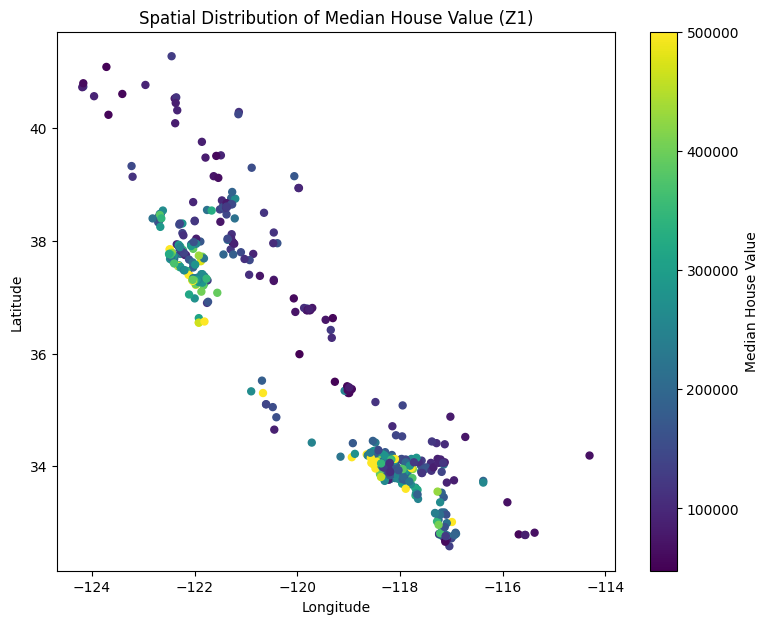

In [15]:
plt.figure(
    figsize=(9,7)
)
plt.scatter(
    coords[:,0],
    coords[:,1],
    c=Z1,
    cmap="viridis",
    s=25
)
plt.colorbar(
    label="Median House Value"
)
plt.xlabel(
    "Longitude"
)
plt.ylabel(
    "Latitude"
)
plt.title(
    "Spatial Distribution of Median House Value (Z1)"
)
plt.show()

## Spatial Distribution of Primary Variable (Z1)

Visualisasi ini digunakan untuk melihat pola persebaran
variabel utama.

Pola warna menunjukkan variasi nilai rumah pada setiap
lokasi pengamatan.

Adanya kelompok lokasi dengan nilai yang serupa menunjukkan
kemungkinan adanya ketergantungan spasial.

Distribusi spasial Median House Value menunjukkan adanya variasi geografis yang tidak bersifat acak. Beberapa lokasi yang berdekatan menunjukkan kecenderungan memiliki nilai rumah yang serupa, sehingga mengindikasikan adanya dependensi spasial yang dapat dimodelkan menggunakan pendekatan Co-Kriging.

## 9.2 — Peta Z2 (Median Income)

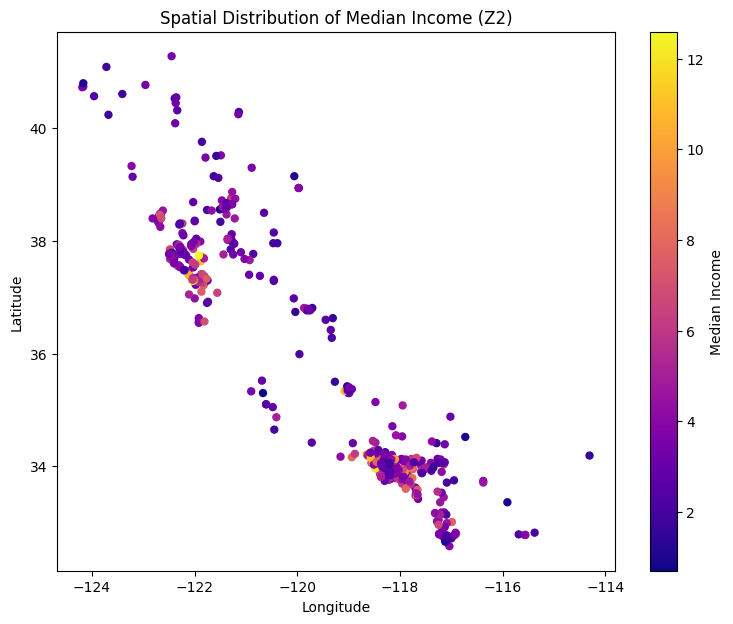

In [16]:
plt.figure(
    figsize=(9,7)
)
plt.scatter(
    coords[:,0],
    coords[:,1],
    c=Z2,
    cmap="plasma",
    s=25
)
plt.colorbar(
    label="Median Income"
)
plt.xlabel(
    "Longitude"
)
plt.ylabel(
    "Latitude"
)
plt.title(
    "Spatial Distribution of Median Income (Z2)"
)
plt.show()

## Spatial Distribution of Secondary Variable (Z2)

Peta ini menunjukkan distribusi spasial variabel pendukung.

Jika Z2 memiliki pola spasial, maka variabel tersebut dapat
memberikan informasi tambahan dalam proses Co-Kriging.

Variabel Median Income menunjukkan pola distribusi spasial yang serupa dengan Median House Value. Kesamaan pola geografis ini menunjukkan bahwa variabel sekunder memiliki informasi tambahan yang potensial untuk meningkatkan estimasi variabel utama melalui metode Co-Kriging.

# 10. VARIOGRAM VARIABEL UTAMA (Z1)
Menganalisis hubungan antara Median House Value dengan jarak.
Kita akan mencari:
- Nugget
- Sill
- Range
- SSE

## 10.1 — Membuat Variogram Z1

In [17]:
V_Z1 = Variogram(
    coords,
    Z1,
    n_lags=15,
    normalize=False
)
print(
    "Variogram Z1 berhasil dibuat"
)

Variogram Z1 berhasil dibuat


## 10.2 — Melihat Parameter Awal

In [18]:
print(
    V_Z1.parameters
)

[np.float64(0.9634171782968507), np.float64(13467097018.54769), 0]


## 10.3 — Plot Variogram Z1

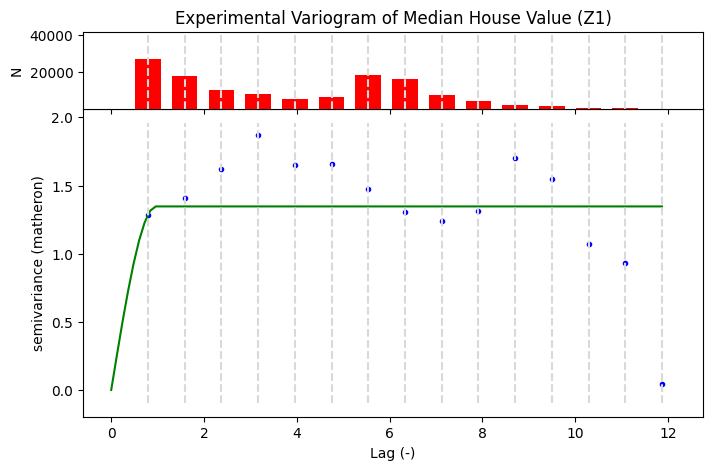

In [19]:
V_Z1.plot()
plt.title(
    "Experimental Variogram of Median House Value (Z1)"
)
plt.show()

## 10.4 — Membandingkan Model Variogram

In [20]:
models = [
    "spherical",
    "exponential",
    "gaussian"
]
hasil_Z1=[]
for m in models:
    V = Variogram(
        coords,
        Z1,
        model=m,
        n_lags=15

    )
    hasil_Z1.append(
        [
            m,
            V.parameters[0],
            V.parameters[1],
            V.parameters[2],
            V.residual_sum_of_squares
        ]

    )
tabel_variogram_Z1 = pd.DataFrame(
    hasil_Z1,
    columns=[
        "Model",
        "Range",
        "Sill",
        "Nugget",
        "SSE"
    ]
)

tabel_variogram_Z1

,Model,Range,Sill,Nugget,SSE
0,spherical,0.963417,1.346710e+10,0,2.679097e+20
1,exponential,0.736655,1.346408e+10,0,2.679465e+20
2,gaussian,0.898636,1.346709e+10,0,2.679098e+20


Berdasarkan hasil pemodelan variogram, model Spherical menghasilkan nilai SSE paling kecil dibandingkan model lainnya, sehingga dipilih sebagai model variogram terbaik untuk variabel Median House Value.
Parameter variogram terbaik menunjukkan nilai range sebesar 0.963417, yang menunjukkan batas jarak dimana hubungan spasial harga rumah masih berlangsung. Setelah melewati jarak tersebut, pengaruh lokasi terhadap nilai rumah semakin berkurang.
Nilai sill sebesar 1.34671 × 10¹⁰ menunjukkan tingkat variasi maksimum yang dapat dijelaskan oleh struktur spasial. Sementara itu, nilai nugget sebesar 0 menunjukkan bahwa variasi mikro atau kesalahan pengukuran pada jarak sangat dekat relatif tidak dominan.
Hasil tersebut menunjukkan bahwa variasi harga rumah di California memiliki pola spasial yang kuat sehingga dapat digunakan sebagai dasar dalam pemodelan Co-Kriging.

# 11. VARIOGRAM VARIABEL SEKUNDER (Z2)

## 11.1 — Membuat Experimental Variogram Z2

In [21]:

V_Z2 = Variogram(
    coords,
    Z2,
    n_lags=15,
    normalize=False
)
print(
    "Variogram Z2 berhasil dibuat"
)

Variogram Z2 berhasil dibuat


## 11.2 — Melihat Parameter Awal Variogram Z2

In [22]:
print(
    "Parameter Variogram Z2"
)


print(
    V_Z2.parameters
)

Parameter Variogram Z2
[np.float64(0.5392924312138411), np.float64(3.4393169989269237), 0]


## 11.3 — Plot Experimental Variogram Z2

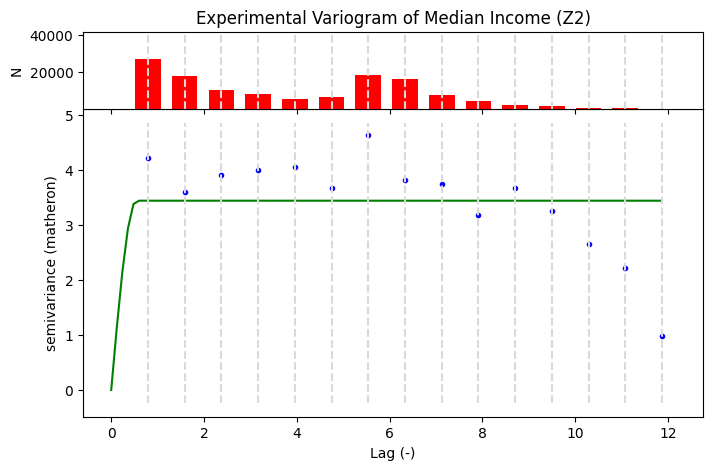

In [23]:
V_Z2.plot()
plt.title(
    "Experimental Variogram of Median Income (Z2)"
)
plt.show()

## 11.4 — Perbandingan Model Variogram Z2

In [24]:
models = [
    "spherical",
    "exponential",
    "gaussian"
]
hasil_Z2 = []
for m in models:
    V = Variogram(
        coords,
        Z2,
        model=m,
        n_lags=15,
        normalize=False
    )
    hasil_Z2.append(
        [
            m,
            V.parameters[0],
            V.parameters[1],
            V.parameters[2],
            V.residual_sum_of_squares
        ]
    )
tabel_variogram_Z2 = pd.DataFrame(
    hasil_Z2,
    columns=[
        "Model",
        "Range",
        "Sill",
        "Nugget",
        "SSE"
    ]
)
tabel_variogram_Z2

,Model,Range,Sill,Nugget,SSE
0,spherical,0.539292,3.439317,0,11.534681
1,exponential,0.001997,3.439317,0,11.534681
2,gaussian,0.115258,3.439317,0,11.534681


Analisis variogram terhadap variabel sekunder Median Income menunjukkan adanya struktur ketergantungan spasial. Hasil pengujian tiga model variogram teoritis menunjukkan bahwa model Spherical mampu merepresentasikan pola spasial dengan parameter range sebesar 0.539292, sill sebesar 3.439317, dan nugget sebesar 0. Nilai tersebut menunjukkan bahwa variasi Median Income dipengaruhi oleh faktor spasial sehingga layak digunakan sebagai variabel sekunder dalam metode Classic Co-Kriging.

# 12 — Analisis Cross Variogram Z1–Z2
## 12. Cross Variogram Z1-Z2

Cross variogram digunakan untuk mengukur hubungan spasial
antara variabel utama (Z1) dan variabel sekunder (Z2).

Berbeda dengan variogram biasa yang hanya melihat hubungan
suatu variabel terhadap dirinya sendiri, cross variogram
menganalisis bagaimana perubahan Z1 berhubungan dengan
perubahan Z2 pada jarak tertentu.

Pada penelitian ini:

Z1 = Median House Value

Z2 = Median Income

Cross variogram menjadi komponen penting dalam Classic Co-Kriging
karena digunakan dalam membangun model koregionalisasi.

## 12.1 — Membuat Fungsi Cross Variogram

In [25]:

def cross_variogram(
    coords,
    z1,
    z2,
    n_lags=15
):
    # Menghitung jarak antar lokasi

    distances = squareform(
        pdist(coords)
    )
    # Selisih nilai Z1

    diff_z1 = (
        z1[:, None]
        -
        z1[None, :]
    )
    # Selisih nilai Z2

    diff_z2 = (
        z2[:, None]
        -
        z2[None, :]
    )
    # Rumus cross variogram

    gamma12 = (
        0.5 *
        diff_z1 *
        diff_z2
    )
    # Membuat kelas jarak
    max_distance = distances.max()
    bins = np.linspace(
        0,
        max_distance,
        n_lags+1
    )
    lag_distance = []
    cross_gamma = []
    for i in range(n_lags):


        mask = (

            distances >= bins[i]

        ) & (

            distances < bins[i+1]

        )
        if np.sum(mask) > 0:


            lag_distance.append(

                (bins[i]+bins[i+1])/2

            )
            cross_gamma.append(

                np.mean(
                    gamma12[mask]
                )

            )
    return (

        np.array(lag_distance),

        np.array(cross_gamma)

    )

## 12.2 — Menghitung Cross Variogram

In [26]:
cross_distance, cross_gamma = cross_variogram(

    coords,

    Z1,

    Z2

)


print(
    "Cross variogram berhasil dihitung"
)

Cross variogram berhasil dihitung


## 12.3 — Visualisasi Cross Variogram

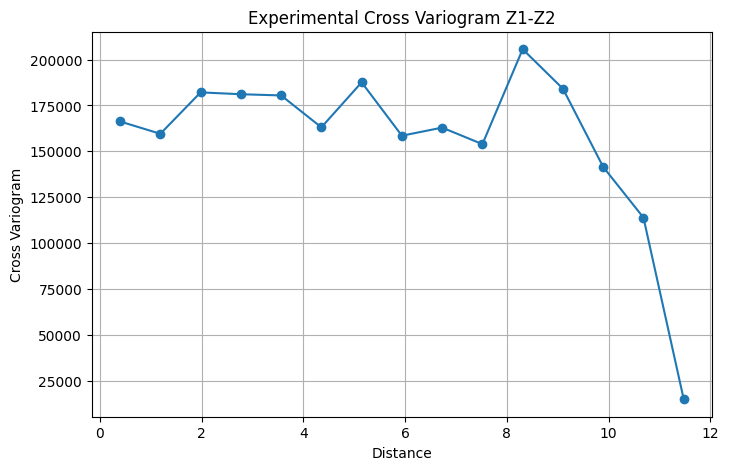

In [27]:
plt.figure(
    figsize=(8,5)
)


plt.plot(

    cross_distance,

    cross_gamma,

    marker="o"

)


plt.xlabel(
    "Distance"
)


plt.ylabel(
    "Cross Variogram"
)


plt.title(
    "Experimental Cross Variogram Z1-Z2"
)


plt.grid()


plt.show()

## 12.4 — Statistik Cross Variogram

In [28]:
cross_summary = pd.DataFrame({

    "Distance":
    cross_distance,

    "Cross_Variogram":
    cross_gamma

})


cross_summary

,Distance,Cross_Variogram
0,0.395733,166285.905654
1,1.187200,159573.910336
2,1.978667,182129.264272
3,2.770134,181130.079289
4,3.561601,180464.111283
5,4.353068,163093.507034
6,5.144535,187594.375107
7,5.936002,158536.130321
8,6.727469,162947.483171
9,7.518936,153930.195597


Cross variogram digunakan untuk menganalisis hubungan spasial antara variabel utama Median House Value (Z1) dan variabel sekunder Median Income (Z2). Berbeda dengan variogram biasa yang hanya menggambarkan hubungan spasial suatu variabel terhadap dirinya sendiri, cross variogram menggambarkan bagaimana perubahan dua variabel terjadi secara bersamaan pada lokasi yang berbeda.
Hasil experimental cross variogram menunjukkan bahwa nilai cross semivariance mengalami perubahan terhadap peningkatan jarak antar lokasi. Pada jarak pendek, nilai cross variogram relatif tinggi yang menunjukkan adanya keterkaitan spasial antara perubahan Median House Value dan Median Income. Seiring bertambahnya jarak, hubungan spasial tersebut mengalami penurunan yang menunjukkan berkurangnya pengaruh spasial antara kedua variabel.
Hasil ini menunjukkan bahwa Median Income memiliki informasi spasial tambahan yang berhubungan dengan Median House Value sehingga dapat digunakan sebagai variabel sekunder dalam pendekatan Classic Co-Kriging.